In [25]:
from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os
import pytz
from datetime import datetime, time, date

#each 5 seconds
utc_offset_h = 2
start_utc = time(0, 00, 00)  #querying i svancouver time, influxdb gives utc
stop_utc = time(23, 45, 00)
date_start = date(2025, 7, 2)
date_stop = date(2025, 7, 6)

vancouver = pytz.timezone("America/Vancouver")

start_local = vancouver.localize(datetime.combine(date_start, start_utc))
stop_local = vancouver.localize(datetime.combine(date_stop, stop_utc))

start_time = start_local.astimezone(pytz.utc)
stop_time = stop_local.astimezone(pytz.utc)

client = query.DBClient()
temp_array_fsgp: TimeSeries = client.query_time_series(start_time, stop_time, field="MosfetTemperatureA")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")

#print(temp_array_expected_aliter)
#this is almost steady state, and expected temperature is roughly 31.8 degrees celsius. note that individual cells do have an upto 5 C difference, which is actually quite a lot.




In [29]:
from datetime import datetime, date, time
import pytz

vancouver = pytz.timezone("America/Vancouver")

date_start = date(2025, 7, 1)
date_stop  = date(2025, 7, 6)

# Local start/end
start_local = vancouver.localize(datetime.combine(date_start, time(23,45,0)))
stop_local  = vancouver.localize(datetime.combine(date_stop, time(0,0,0)))

# Convert to UTC
start_utc = start_local.astimezone(pytz.utc)
stop_utc  = stop_local.astimezone(pytz.utc)

print("Start UTC:", start_utc)  # 2025-07-02 07:00:00+00:00
print("Stop UTC:", stop_utc)    # 2025-07-07 06:45:00+00:00

client = query.DBClient()
temp_array_fsgp = client.query_time_series(start_utc, stop_utc, field="MosfetTemperatureA")
speed_kph       = client.query_time_series(start_utc, stop_utc, "MotorRotatingSpeed")


Start UTC: 2025-07-02 06:45:00+00:00
Stop UTC: 2025-07-06 07:00:00+00:00


In [30]:
import pandas as pd

#resampling influx data so that i can fit it with irradiance data (queried every 15 minutes)

ts = temp_array_fsgp
timestamps = pd.to_datetime(ts.datetime_x_axis, utc=True)
values = ts.data

df = pd.DataFrame({"value": values}, index=timestamps)
df_15m = df.resample("15T").mean()

print(df_15m.head())
print(df_15m.tail())


                               value
2025-07-01 23:45:00+00:00  26.032398
2025-07-02 00:00:00+00:00  25.083505
2025-07-02 00:15:00+00:00  24.787958
2025-07-02 00:30:00+00:00  24.492412
2025-07-02 00:45:00+00:00  24.675365
                               value
2025-07-05 13:00:00+00:00  38.086209
2025-07-05 13:15:00+00:00  36.774657
2025-07-05 13:30:00+00:00  35.463106
2025-07-05 13:45:00+00:00  34.271664
2025-07-05 14:00:00+00:00  34.174615


C:\Users\sanar\AppData\Local\Temp\ipykernel_31364\2898644639.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m = df.resample("15T").mean()


querying from openmeteo to get solar irradiance data

- this is hourly irradiance over 4 days


In [49]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
    "latitude": 36.9760,
    "longitude": 86.4491,
    "start_date": "2025-07-02",
    "end_date": "2025-07-05",
    "minutely_15": ["temperature_2m", "wind_speed_10m", "shortwave_radiation_instant"],
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_shortwave_radiation_instant = minutely_15.Variables(1).ValuesAsNumpy()
minutely_15_wind_speed_10m = minutely_15.Variables(2).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
    start=pd.to_datetime(minutely_15.Time(), unit="s", utc=True),
    end=pd.to_datetime(minutely_15.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=minutely_15.Interval()),
    inclusive="left"
)}

minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["shortwave_radiation_instant"] = minutely_15_shortwave_radiation_instant
minutely_15_data["wind_speed_10m"] = minutely_15_wind_speed_10m

minutely_15_dataframe = pd.DataFrame(data=minutely_15_data)
print("\nMinutely15 data\n", minutely_15_dataframe)

Coordinates: 37.0°N 86.5°E
Elevation: 5139.0 m asl
Timezone difference to GMT+0: 0s

Minutely15 data
                          date  temperature_2m  shortwave_radiation_instant  \
0   2025-07-02 00:00:00+00:00           -2.20                     5.588703   
1   2025-07-02 00:15:00+00:00           -2.15                     5.351785   
2   2025-07-02 00:30:00+00:00           -2.15                     5.014219   
3   2025-07-02 00:45:00+00:00           -2.05                     4.680000   
4   2025-07-02 01:00:00+00:00           -1.95                     4.680000   
..                        ...             ...                          ...   
379 2025-07-05 22:45:00+00:00           -2.00                     8.496305   
380 2025-07-05 23:00:00+00:00           -1.95                     8.788720   
381 2025-07-05 23:15:00+00:00           -1.95                     9.085988   
382 2025-07-05 23:30:00+00:00           -1.90                     9.199390   
383 2025-07-05 23:45:00+00:00           

In [50]:
minutely_15_dataframe = minutely_15_dataframe[minutely_15_dataframe['date']<'2025-07-05 14:15:00']

In [51]:
minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["shortwave_radiation_instant"] = minutely_15_shortwave_radiation_instant
minutely_15_data["wind_speed_10m"] = minutely_15_wind_speed_10m

In [46]:
minutely_15_dataframe.tail()


In [52]:
len(minutely_15_dataframe)

345

In [55]:
print("\nMinutely15 data\n", minutely_15_dataframe)



Minutely15 data
                          date  temperature_2m  shortwave_radiation_instant  \
0   2025-07-02 00:00:00+00:00           -2.20                     5.588703   
1   2025-07-02 00:15:00+00:00           -2.15                     5.351785   
2   2025-07-02 00:30:00+00:00           -2.15                     5.014219   
3   2025-07-02 00:45:00+00:00           -2.05                     4.680000   
4   2025-07-02 01:00:00+00:00           -1.95                     4.680000   
..                        ...             ...                          ...   
340 2025-07-05 13:00:00+00:00            1.15                    29.548521   
341 2025-07-05 13:15:00+00:00            0.90                    27.475807   
342 2025-07-05 13:30:00+00:00            0.65                    25.202570   
343 2025-07-05 13:45:00+00:00            0.40                    22.461807   
344 2025-07-05 14:00:00+00:00            0.25                    20.056877   

     wind_speed_10m  
0        124.831741  
1

In [57]:
print(df_15m)

                               value
2025-07-02 00:00:00+00:00  25.083505
2025-07-02 00:15:00+00:00  24.787958
2025-07-02 00:30:00+00:00  24.492412
2025-07-02 00:45:00+00:00  24.675365
2025-07-02 01:00:00+00:00  25.388537
...                              ...
2025-07-05 13:00:00+00:00  38.086209
2025-07-05 13:15:00+00:00  36.774657
2025-07-05 13:30:00+00:00  35.463106
2025-07-05 13:45:00+00:00  34.271664
2025-07-05 14:00:00+00:00  34.174615

[345 rows x 1 columns]


In [53]:
df_15m = df_15m.iloc[1:]

minutely open meteo data starts at 2 july, 12am and goes to 6 july 22 45
therefore on influx i query for 1 july 10  pm to 6 july 20 45


utc i s2 hours ahead of vancouver



Plot some relevant data. this will further be used to generate the relevant coefficients

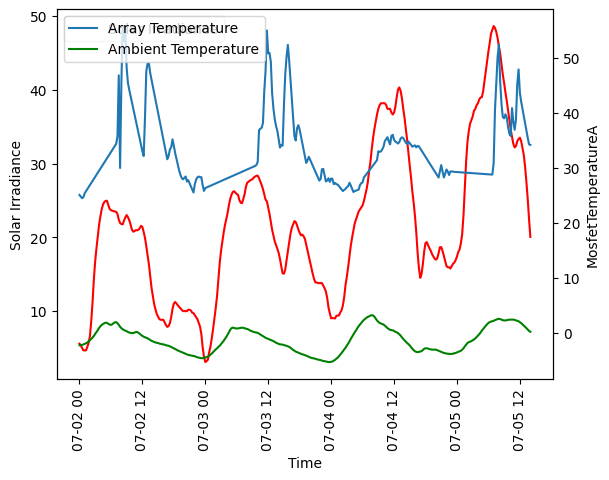

In [58]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(df_15m.index, df_15m, label="Array Temperature")
plt.plot(minutely_15_dataframe['date'], minutely_15_dataframe['temperature_2m'], color='green', label="Ambient Temperature")
# plt.plot(minutely_15_data['date'], minutely_15_data['wind_speed_10m'], color = 'blue', label = "Wind Speed 10m")
# plt.plot(speed_kph.datetime_x_axis, speed_kph, color = 'yellow', label = "Speed KPH")

ax1.plot(minutely_15_dataframe['date'], minutely_15_dataframe['shortwave_radiation_instant'], color="red",
         label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

In [6]:
len(df_15m)

381

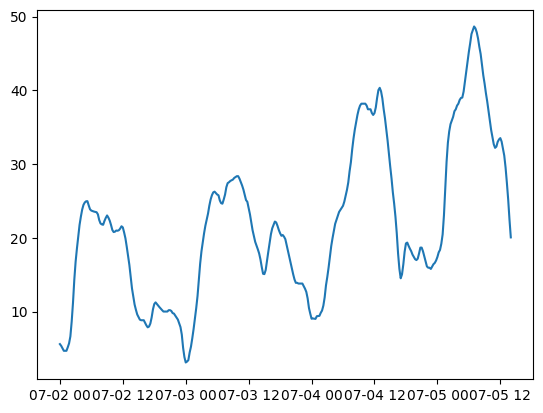

In [60]:
plt.plot(minutely_15_dataframe['date'], minutely_15_dataframe['shortwave_radiation_instant'])

In [7]:
len(minutely_15_data['date'])

480

In [64]:
from v4.array_temperature.arrayTemperatureModel import arrayTemperatureModel
def model(u0, u1):
    return arrayTemperatureModel(minutely_15_dataframe['temperature_2m'], minutely_15_dataframe['shortwave_radiation_instant'], 0, u0, u1)



0     -1.945968
1     -1.906737
2     -1.922081
3     -1.837273
4     -1.737273
         ...   
340    2.493114
341    2.148900
342    1.795571
343    1.420991
344    1.161676
Length: 345, dtype: float32


In [68]:
model2 = model(12, 0.8)
print(model2.calculateArrayTemperature())
faiman_temp = model2.calculateArrayTemperature()

0     -1.734275
1     -1.704018
2     -1.732149
3     -1.660000
4     -1.560000
         ...   
340    3.612377
341    3.189651
342    2.750214
343    2.271817
344    1.921406
Length: 345, dtype: float32


(array([20271. , 20271.5, 20272. , 20272.5, 20273. , 20273.5, 20274. ,
        20274.5]),
 [Text(20271.0, 0, '07-02 00'),
  Text(20271.5, 0, '07-02 12'),
  Text(20272.0, 0, '07-03 00'),
  Text(20272.5, 0, '07-03 12'),
  Text(20273.0, 0, '07-04 00'),
  Text(20273.5, 0, '07-04 12'),
  Text(20274.0, 0, '07-05 00'),
  Text(20274.5, 0, '07-05 12')])

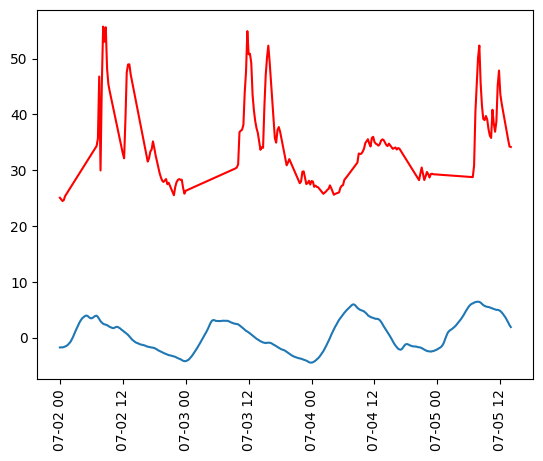

In [69]:
plt.plot(df_15m.index, df_15m, color = 'red')
plt.plot(df_15m.index, faiman_temp)
plt.xticks(rotation = 90)
